In [37]:
import pandas as pd     
import numpy as np
import glob
import os
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist


TRAIN_DIR = "./nfl-big-data-bowl-2026-prediction/train"              
TEST_INPUT = "./nfl-big-data-bowl-2026-prediction/test_input.csv"     
TEST_TEMPLATE = "./nfl-big-data-bowl-2026-prediction/test.csv"    


# normalization of data . convert left side of the orintation to the right side.
def normalize_direction(df):
    df = df.copy()   # make a copy of real data.
    if 'play_direction' in df.columns:  # check for player directions either left or right
        left = df["play_direction"] == "left"    # filter the columns that have directions - left;
        df.loc[left, "x"] = 120 - df.loc[left, "x"]    # total depth of the  ground is 120 yards
        df.loc[left, "y"] = 53.3 - df.loc[left, "y"]  # total width of  the ground is 53.3 yards
        if 'o' in df.columns: df.loc[left, "o"] = (df.loc[left, "o"] + 180) % 360   # change the orientation by rotating.
        if 'dir' in df.columns: df.loc[left, "dir"] = (df.loc[left, "dir"] + 180) % 360   # change the direction also 
    return df


#this function is basically compute pressure, separation and distance between offence and nearest defender.
def compute_anatomy_features(df):
    """Calculates Separation (Target->Defense) and Pressure (QB->Defense)."""
    # filter out the columns those having importaant role in analysis.
    cols = ['game_id', 'play_id', 'frame_id', 'nfl_id', 'player_side', 'player_role', 'x', 'y']
    # make a dataframe using above columns 
    df_sub = df[[c for c in cols if c in df.columns]].copy()
    
    defense = df_sub[df_sub.player_side == 'Defense']    # choose the rows in which player_side is Defense.
    passer = df_sub[df_sub.player_role == 'Passer']      # choose the rows in which player_side is passed.
    offense = df_sub[df_sub.player_side == 'Offense']    # choose the rows in which player_side is offense.
    
    results = []  # resultant array for storing the pressure and separations 
    # Process each frame to find relative distances
    for (g, p, f), def_grp in defense.groupby(['game_id', 'play_id', 'frame_id']):
        def_coords = def_grp[['x', 'y']].values
        
        # QB Pressure: distance to nearest defender
        qb_grp = passer[(passer.game_id == g) & (passer.play_id == p) & (passer.frame_id == f)]
        pressure = np.nan       # declaration  of pressure as NaN value.
        if not qb_grp.empty:
            pressure = cdist(qb_grp[['x', 'y']].values, def_coords).min()  # assign the pressure.
            
        # Separation: distance for each offensive player to nearest defender
        off_grp = offense[(offense.game_id == g) & (offense.play_id == p) & (offense.frame_id == f)]
        if off_grp.empty: continue

        
        # distance between each offense player and defenders
        dists = cdist(off_grp[['x', 'y']].values, def_coords)
        min_dists = dists.min(axis=1) # choose the minimum distance.maximum separation.
        
        for i, nfl_id in enumerate(off_grp.nfl_id.values):
            # append the result to the resultant array.
            results.append({
                'game_id': g, 'play_id': p, 'frame_id': f, 'nfl_id': nfl_id, 
                'pressure': pressure, 'separation': min_dists[i]
            }) 

    # create a Feature DataFrame. in which we store all features that will use in predicition.
    feat_df = pd.DataFrame(results)    
    if feat_df.empty: return df  # if feat_df is empty it is a Fallback.
        # other wise returen the merged data with specified features.
    return df.merge(feat_df, on=['game_id', 'play_id', 'frame_id', 'nfl_id'], how='left')



# fetching the data using glob library.
input_files = sorted(glob.glob(f"{TRAIN_DIR}/input_*.csv"))
FEATURES = ['x', 'y', 's', 'a', 'dir', 'o', 'separation', 'pressure']  # feature that we wanna work on.
TARGETS = ['x_target', 'y_target']   # features that will be predict.

all_X, all_y = [], []

for f_in in input_files:
    f_out = f_in.replace("input_", "output_")   # filter input and output files.
    if not os.path.exists(f_out): continue   # exception handling.
    
    # Load and process
    df_in = compute_anatomy_features(normalize_direction(pd.read_csv(f_in)))    # compute anatomy for the input file 
    df_out = pd.read_csv(f_out)    # read the output file.
    
    # Merge features with targets after computing the antomy.
    merged = df_in.merge(df_out, on=['game_id', 'play_id', 'nfl_id', 'frame_id'], 
                         how='inner', suffixes=('', '_target'))

    # clean the data just filreing the required columns.
    clean_data = merged.dropna(subset=FEATURES + TARGETS)
    all_X.append(clean_data[FEATURES])  # load all input data into one file
    all_y.append(clean_data[TARGETS])   # load all output data into one file 

print("Data is loaded")
X_train = pd.concat(all_X)   # concate the input data.
y_train = pd.concat(all_y) #concate the output data.

# use StandardScaler for scaling the data because we have value in float format:
# for scaler mean=0 and std=1
scaler = StandardScaler()  
X_train_scaled = scaler.fit_transform(X_train)   # transform the input training data using StandardScaler.



Data is loaded


AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [12]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


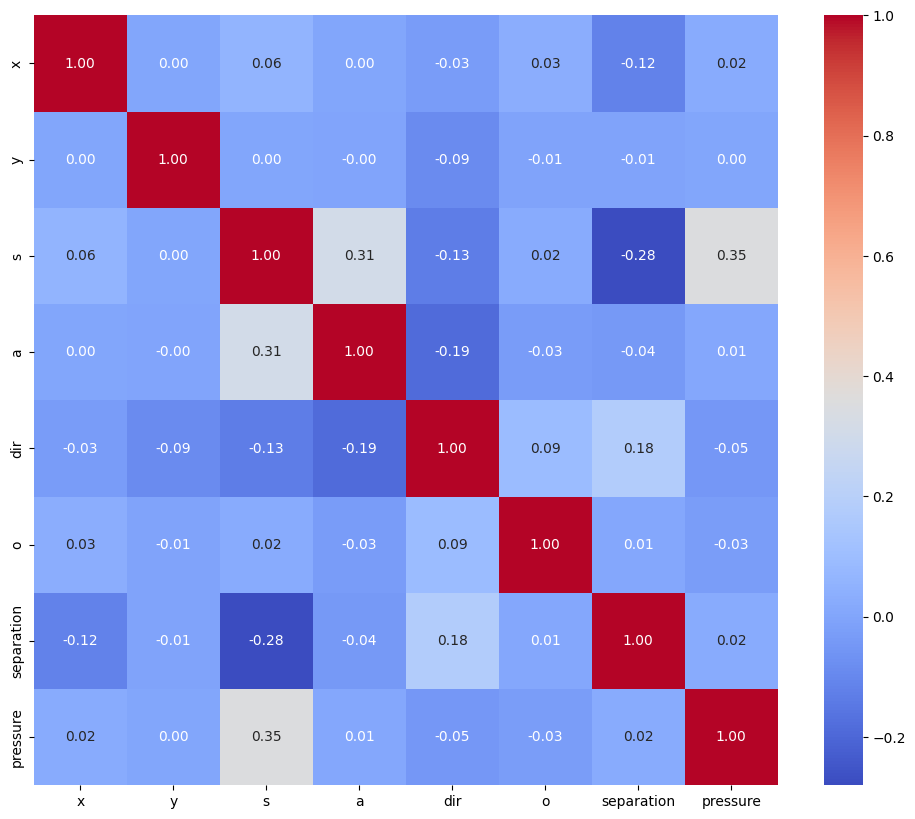

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()


In [22]:
# Basic stats
print(df_in[['pressure', 'separation']].describe())

# Missing values
print(df_in[['pressure', 'separation']].isna().mean())


            pressure     separation
count  115978.000000  115978.000000
mean       11.223696       6.148971
std         3.220869       3.888799
min         2.305211       0.250000
25%         9.168975       2.940102
50%        10.736042       5.574343
75%        13.135814       8.750344
max        28.321035      28.321035
pressure      0.545036
separation    0.545036
dtype: float64


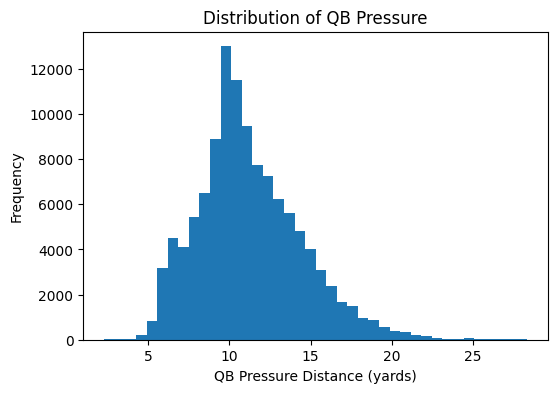

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df_in['pressure'].dropna(), bins=40)
plt.xlabel("QB Pressure Distance (yards)")
plt.ylabel("Frequency")
plt.title("Distribution of QB Pressure")
plt.show()


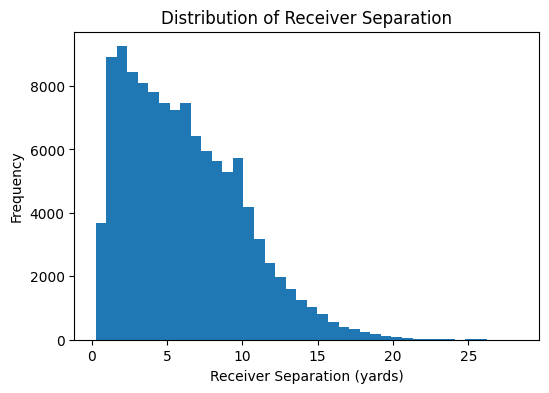

In [24]:
plt.figure(figsize=(6,4))
plt.hist(df_in['separation'].dropna(), bins=40)
plt.xlabel("Receiver Separation (yards)")
plt.ylabel("Frequency")
plt.title("Distribution of Receiver Separation")
plt.show()


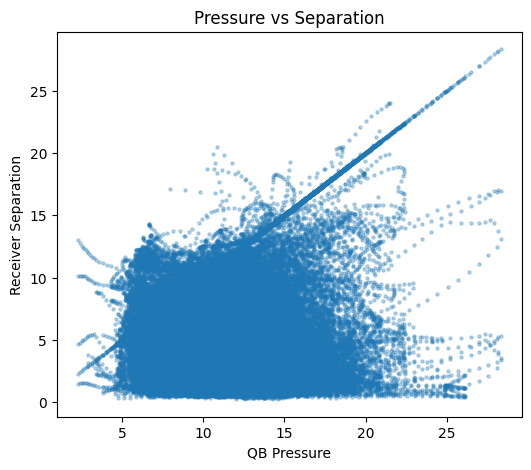

In [25]:
plt.figure(figsize=(6,5))
plt.scatter(
    df_in['pressure'],
    df_in['separation'],
    alpha=0.3,
    s=5
)
plt.xlabel("QB Pressure")
plt.ylabel("Receiver Separation")
plt.title("Pressure vs Separation")
plt.show()


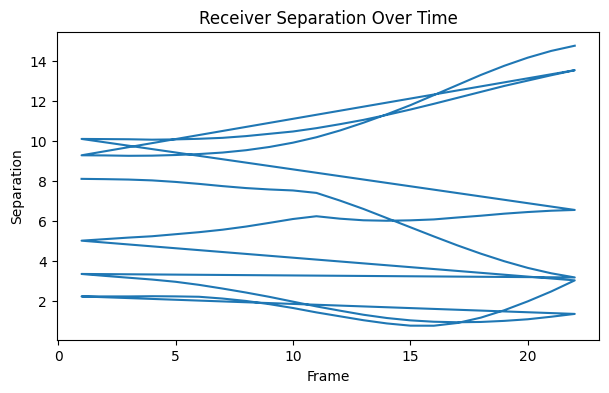

In [26]:
sample_play = df_in[
    (df_in.game_id == df_in.game_id.iloc[0]) &
    (df_in.play_id == df_in.play_id.iloc[0])
]

plt.figure(figsize=(7,4))
plt.plot(sample_play['frame_id'], sample_play['separation'])
plt.xlabel("Frame")
plt.ylabel("Separation")
plt.title("Receiver Separation Over Time")
plt.show()


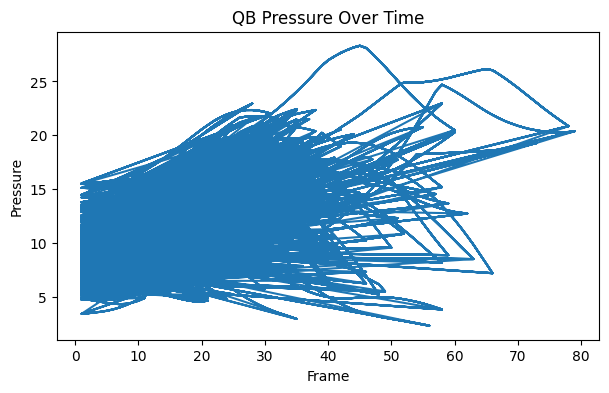

In [36]:
qb_frames = df_in[df_in['pressure'].notna()]

plt.figure(figsize=(7,4))
plt.plot(qb_frames['frame_id'], qb_frames['pressure'])
plt.xlabel("Frame")
plt.ylabel("Pressure")
plt.title("QB Pressure Over Time")
plt.show()


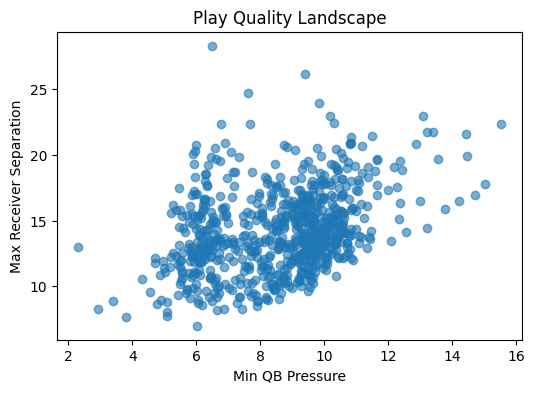

In [30]:
plt.figure(figsize=(6,4))
plt.scatter(
    play_level['min_pressure'],
    play_level['max_separation'],
    alpha=0.6
)
plt.xlabel("Min QB Pressure")
plt.ylabel("Max Receiver Separation")
plt.title("Play Quality Landscape")
plt.show()


In [31]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 159800 entries, 42 to 29620
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   x           159800 non-null  float64
 1   y           159800 non-null  float64
 2   s           159800 non-null  float64
 3   a           159800 non-null  float64
 4   dir         159800 non-null  float64
 5   o           159800 non-null  float64
 6   separation  159800 non-null  float64
 7   pressure    159800 non-null  float64
dtypes: float64(8)
memory usage: 11.0 MB
